In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [63]:
CLASSIF_METHODS = ["ClassifWrapSA(LogisticRegression)",
                   "ClassifWrapSA(SVC)",
                   "ClassifWrapSA(KNeighborsClassifier)",
                   "ClassifWrapSA(DecisionTreeClassifier)",
                   "ClassifWrapSA(RandomForestClassifier)",
                   "ClassifWrapSA(GradientBoostingClassifier)"]

REGR_METHODS = ["RegrWrapSA(ElasticNet)",
                "RegrWrapSA(DecisionTreeRegressor)",
                "RegrWrapSA(RandomForestRegressor)",
                "RegrWrapSA(GradientBoostingRegressor)",
                "RegrWrapSA(SVR)",
                "RegrWrapSA(KNeighborsRegressor)"]

SURV_METHODS = ["SAWrapSA(KaplanMeierFitter)",
                "CoxPHSurvivalAnalysis",
                "RandomSurvivalForest",
                "SurvivalTree",
                "GradientBoostingSurvivalAnalysis",
                "CRAID",
                "ParallelBootstrapCRAID"]

In [64]:
df = pd.read_excel('UI/tables/pbc.xlsx')

In [65]:
df_metrics = df[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                 'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

In [66]:
bad_example = ["BAD", 0.5, 0.25, 0.5, 100000.0, -10.0, 0.5, 1.0, 100000.0]
good_example = ["GOOD", 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0]

df_metrics = pd.concat([df_metrics, pd.DataFrame([bad_example, good_example],
                                                 columns=df_metrics.columns)], ignore_index=True)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [67]:
df_metrics = df_metrics[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                #  'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

### TSNE Visualization

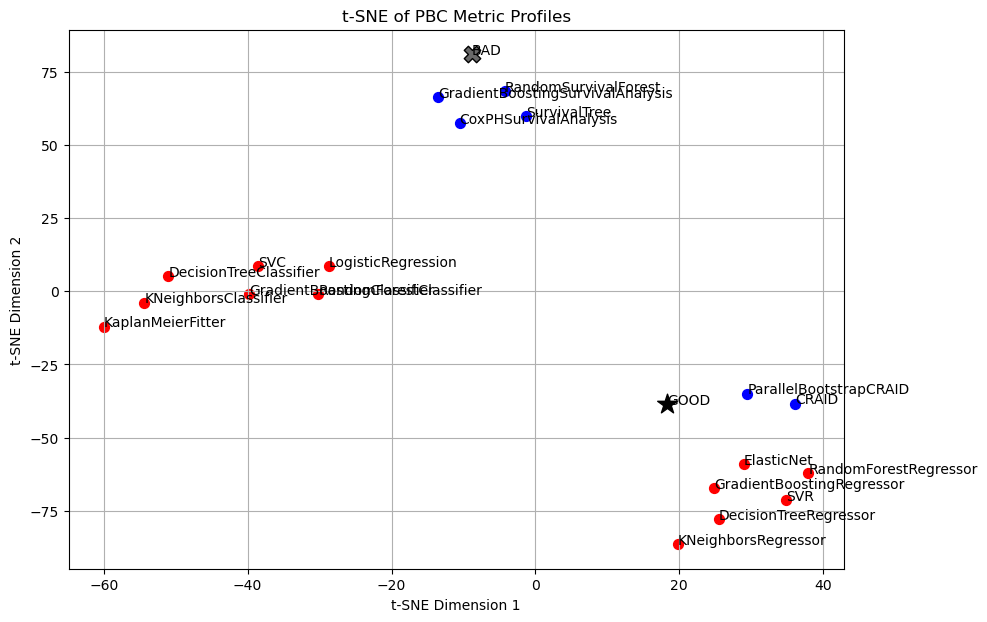

In [68]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# t-SNE here shows similarity of metric profiles on PBC, not the global leaderboard rank.
tsne_df = df_metrics.copy()
real_mask = ~tsne_df['METHOD'].isin(['GOOD', 'BAD'])
tsne_features = tsne_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    tsne_features[col] = -tsne_features[col]

scaler = StandardScaler().fit(tsne_features.loc[real_mask])
scaled_metrics = scaler.transform(tsne_features)
perplexity = max(2, min(5, len(tsne_df) - 1))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
for i, method in enumerate(tsne_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(tsne_results[i, 0], tsne_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (tsne_results[i, 0], tsne_results[i, 1]))
plt.title('t-SNE of PBC Metric Profiles')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid()
plt.show()

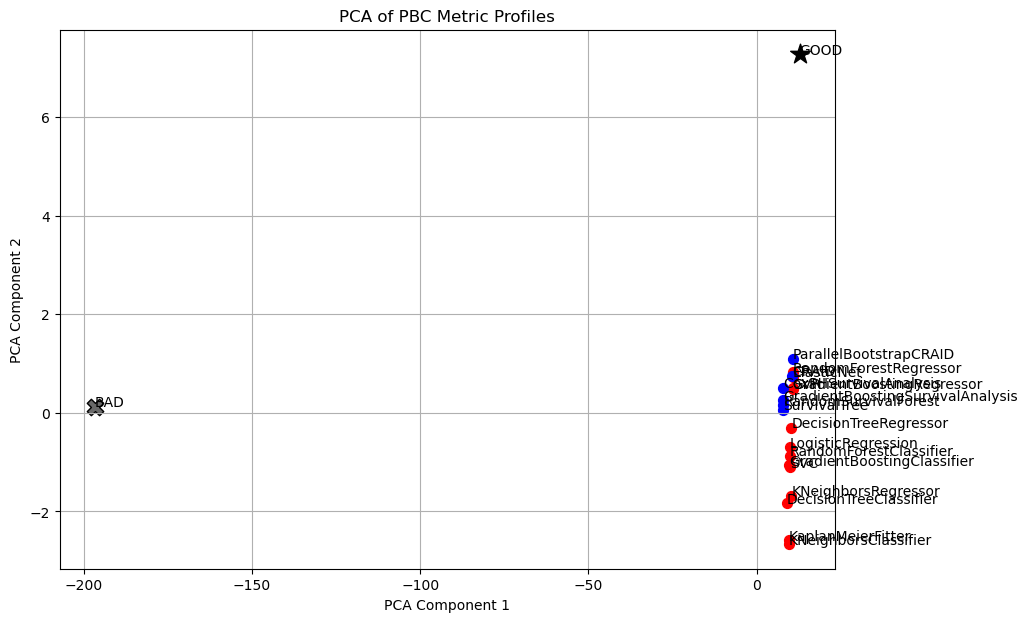

In [69]:
### PCA Visualization

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_df = df_metrics.copy()
real_mask = ~pca_df['METHOD'].isin(['GOOD', 'BAD'])
pca_features = pca_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    pca_features[col] = -pca_features[col]

scaler = StandardScaler().fit(pca_features.loc[real_mask])
scaled_metrics = scaler.transform(pca_features)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(pca_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(pca_results[i, 0], pca_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (pca_results[i, 0], pca_results[i, 1]))

plt.title('PCA of PBC Metric Profiles')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid()
plt.show()

d:\Users\DimonZhi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


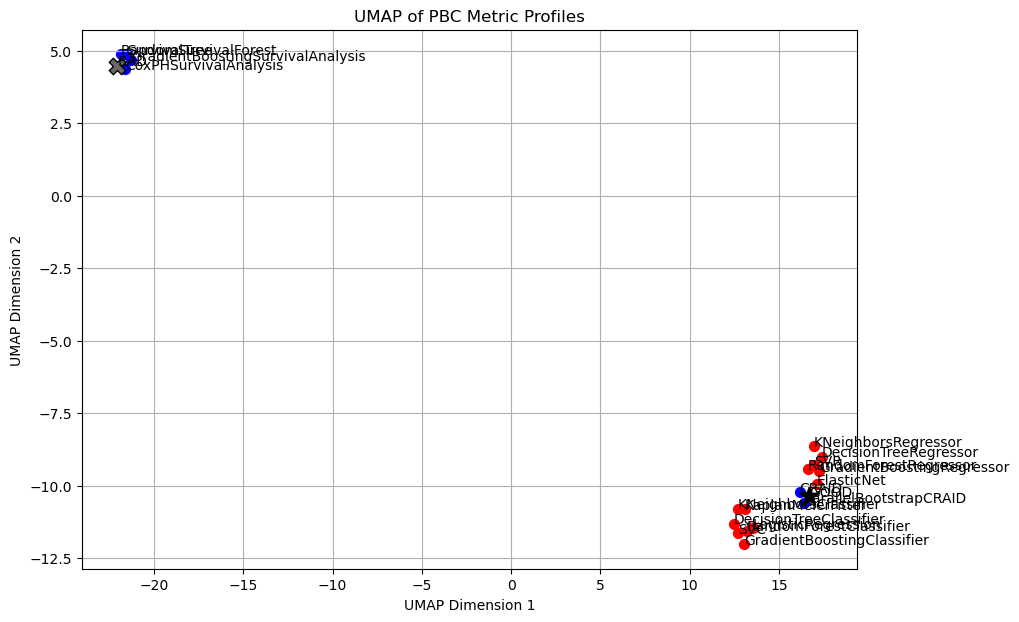

In [70]:
### UMAP Visualization

from umap import UMAP
from sklearn.preprocessing import StandardScaler

umap_df = df_metrics.copy()
real_mask = ~umap_df['METHOD'].isin(['GOOD', 'BAD'])
umap_features = umap_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    umap_features[col] = -umap_features[col]

scaler = StandardScaler().fit(umap_features.loc[real_mask])
scaled_metrics = scaler.transform(umap_features)
n_neighbors = max(2, min(8, len(umap_df) - 1))

umap = UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42, min_dist=0.1)
umap_results = umap.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(umap_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(umap_results[i, 0], umap_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (umap_results[i, 0], umap_results[i, 1]))

plt.title('UMAP of PBC Metric Profiles')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid()
plt.show()

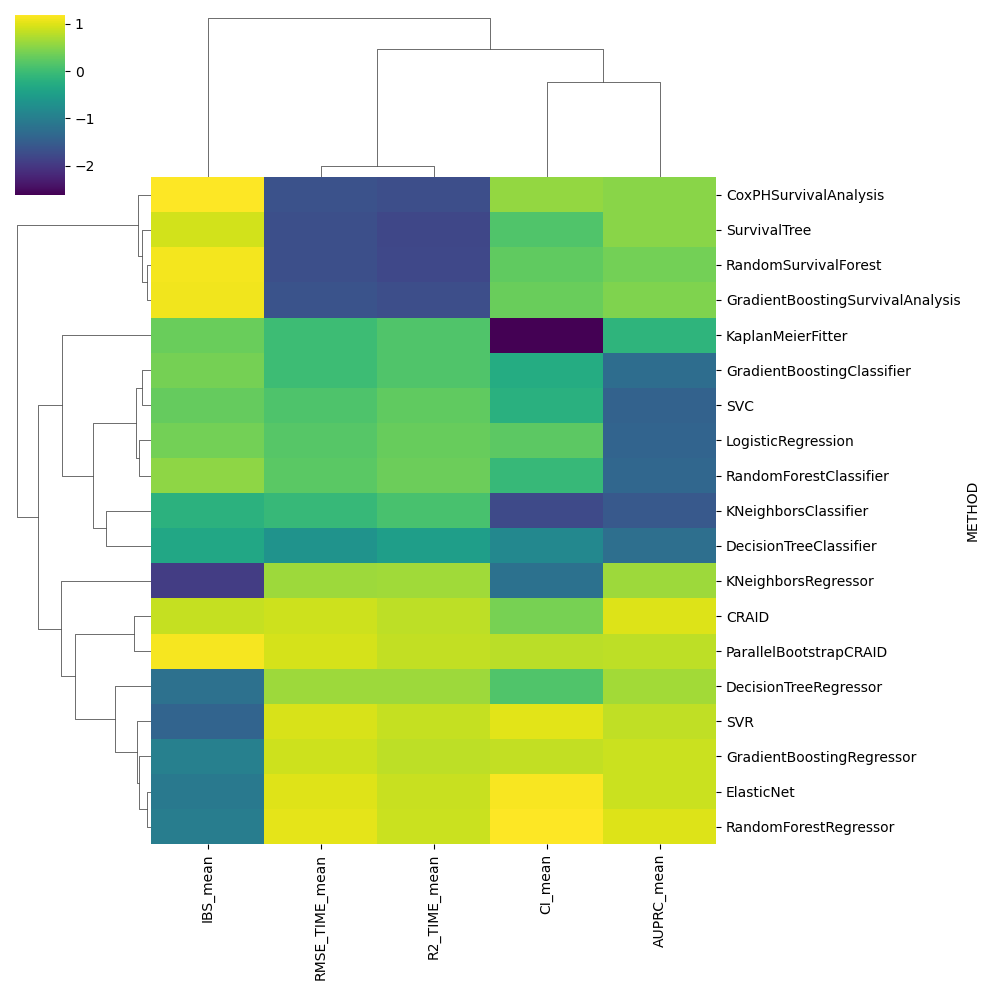

In [71]:
import seaborn as sns

cluster_df = df_metrics[~df_metrics['METHOD'].isin(['GOOD', 'BAD'])].copy()
cluster_features = cluster_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    cluster_features[col] = -cluster_features[col]
cluster_features.index = cluster_df['METHOD']

sns.clustermap(cluster_features.astype(float),
               cmap='viridis',
               z_score=1,
               col_cluster=True,
               row_cluster=True)

,Method,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,group,delta
0,RandomForestClassifier,2.6,11.4,classification,-8.8
1,GradientBoostingClassifier,3.4,12.6,classification,-9.2
2,GradientBoostingSurvivalAnalysis,3.6,2.2,survival,1.4
3,ParallelBootstrapCRAID,4.4,1.6,survival,2.8
4,RandomSurvivalForest,5.4,3.6,survival,1.8
5,LogisticRegression,6.2,10.2,classification,-4.0
6,CRAID,8.0,6.6,survival,1.4
7,CoxPHSurvivalAnalysis,8.0,6.8,survival,1.2
8,SVC,8.0,13.8,classification,-5.8
9,RandomForestRegressor,11.8,8.8,regression,3.0


,Method,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,delta,group
0,RandomForestClassifier,2.6,11.4,-8.8,classification
1,GradientBoostingClassifier,3.4,12.6,-9.2,classification
2,GradientBoostingSurvivalAnalysis,3.6,2.2,1.4,survival
3,ParallelBootstrapCRAID,4.4,1.6,2.8,survival
4,RandomSurvivalForest,5.4,3.6,1.8,survival
5,LogisticRegression,6.2,10.2,-4.0,classification
6,CRAID,8.0,6.6,1.4,survival
7,CoxPHSurvivalAnalysis,8.0,6.8,1.2,survival
8,SVC,8.0,13.8,-5.8,classification
9,RandomForestRegressor,11.8,8.8,3.0,regression


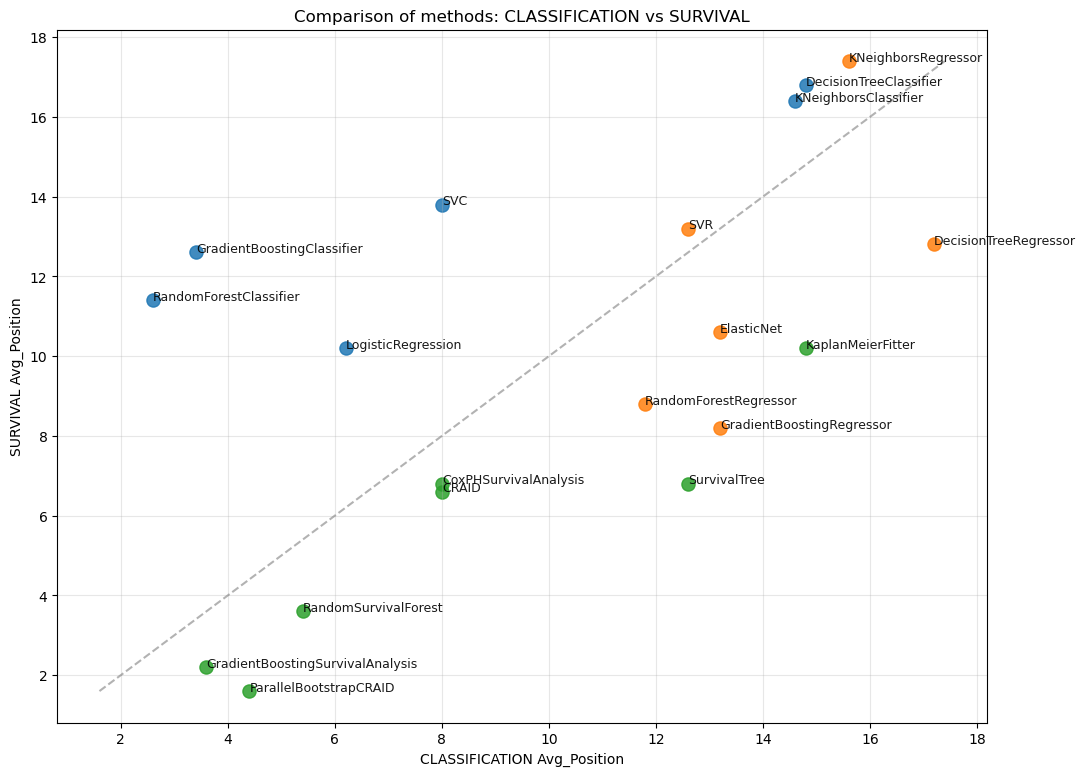

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Какие задачи сравниваем по осям
TASK_X = "CLASSIFICATION"
TASK_Y = "SURVIVAL"
USE_COL = "Avg_Position"   # можно заменить на "Avg_RankSum"

path = "UI/tables/leaderboards_by_task.xlsx"

sheet_map = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
    "ALL": "OVERALL_ALL",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

def method_group(method):
    if method in CLASSIF_MODELS:
        return "classification"
    if method in REGR_MODELS:
        return "regression"
    if method in SURV_MODELS:
        return "survival"
    return "other"

colors = {
    "classification": "tab:blue",
    "regression": "tab:orange",
    "survival": "tab:green",
    "other": "tab:gray",
}

df_x = pd.read_excel(path, sheet_name=sheet_map[TASK_X])
df_y = pd.read_excel(path, sheet_name=sheet_map[TASK_Y])

df_x = df_x[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_X}_{USE_COL}"})
df_y = df_y[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_Y}_{USE_COL}"})

cmp = df_x.merge(df_y, on="Method", how="inner")
cmp["group"] = cmp["Method"].apply(method_group)
cmp["delta"] = cmp[f"{TASK_X}_{USE_COL}"] - cmp[f"{TASK_Y}_{USE_COL}"]
cmp = cmp.sort_values([f"{TASK_X}_{USE_COL}", f"{TASK_Y}_{USE_COL}"]).reset_index(drop=True)

display(cmp)

rank_table = cmp[[
    "Method",
    f"{TASK_X}_{USE_COL}",
    f"{TASK_Y}_{USE_COL}",
    "delta",
    "group"
]].copy()

display(rank_table)

plt.figure(figsize=(12, 9))

for _, row in cmp.iterrows():
    x = row[f"{TASK_X}_{USE_COL}"]
    y = row[f"{TASK_Y}_{USE_COL}"]
    c = colors[row["group"]]

    plt.scatter(x, y, color=c, s=90, alpha=0.85)
    plt.annotate(row["Method"], (x, y), fontsize=9, alpha=0.9)


xy_min = min(cmp[f"{TASK_X}_{USE_COL}"].min(), cmp[f"{TASK_Y}_{USE_COL}"].min())
xy_max = max(cmp[f"{TASK_X}_{USE_COL}"].max(), cmp[f"{TASK_Y}_{USE_COL}"].max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)

plt.xlabel(f"{TASK_X} {USE_COL}")
plt.ylabel(f"{TASK_Y} {USE_COL}")
plt.title(f"Comparison of methods: {TASK_X} vs {TASK_Y}")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TASK_X = "SURVIVAL"
TASK_Y = "REGRESSION"
USE_COL = "Avg_Position"

path = "UI/tables/leaderboards_by_task.xlsx"

sheet_map = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
    "ALL": "OVERALL_ALL",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

def method_group(method):
    if method in CLASSIF_MODELS:
        return "classification"
    if method in REGR_MODELS:
        return "regression"
    if method in SURV_MODELS:
        return "survival"
    return "other"

colors = {
    "classification": "tab:blue",
    "regression": "tab:orange",
    "survival": "tab:green",
    "other": "tab:gray",
}

df_x = pd.read_excel(path, sheet_name=sheet_map[TASK_X])
df_y = pd.read_excel(path, sheet_name=sheet_map[TASK_Y])

df_x = df_x[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_X}_{USE_COL}"})
df_y = df_y[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_Y}_{USE_COL}"})

cmp = df_x.merge(df_y, on="Method", how="inner")
cmp["group"] = cmp["Method"].apply(method_group)
cmp["delta"] = cmp[f"{TASK_X}_{USE_COL}"] - cmp[f"{TASK_Y}_{USE_COL}"]
cmp = cmp.sort_values([f"{TASK_X}_{USE_COL}", f"{TASK_Y}_{USE_COL}"]).reset_index(drop=True)

display(cmp)

rank_table = cmp[[
    "Method",
    f"{TASK_X}_{USE_COL}",
    f"{TASK_Y}_{USE_COL}",
    "delta",
    "group"
]].copy()

display(rank_table)

plt.figure(figsize=(12, 9))

for _, row in cmp.iterrows():
    x = row[f"{TASK_X}_{USE_COL}"]
    y = row[f"{TASK_Y}_{USE_COL}"]
    c = colors[row["group"]]

    plt.scatter(x, y, color=c, s=90, alpha=0.85)
    plt.annotate(row["Method"], (x, y), fontsize=9, alpha=0.9)

xy_min = min(cmp[f"{TASK_X}_{USE_COL}"].min(), cmp[f"{TASK_Y}_{USE_COL}"].min())
xy_max = max(cmp[f"{TASK_X}_{USE_COL}"].max(), cmp[f"{TASK_Y}_{USE_COL}"].max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)

plt.xlabel(f"{TASK_X} {USE_COL}")
plt.ylabel(f"{TASK_Y} {USE_COL}")
plt.title(f"Comparison of methods: {TASK_X} vs {TASK_Y}")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TASK_X = "REGRESSION"
TASK_Y = "CLASSIFICATION"
USE_COL = "Avg_Position"

path = "UI/tables/leaderboards_by_task.xlsx"

sheet_map = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
    "ALL": "OVERALL_ALL",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

def method_group(method):
    if method in CLASSIF_MODELS:
        return "classification"
    if method in REGR_MODELS:
        return "regression"
    if method in SURV_MODELS:
        return "survival"
    return "other"

colors = {
    "classification": "tab:blue",
    "regression": "tab:orange",
    "survival": "tab:green",
    "other": "tab:gray",
}

df_x = pd.read_excel(path, sheet_name=sheet_map[TASK_X])
df_y = pd.read_excel(path, sheet_name=sheet_map[TASK_Y])

df_x = df_x[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_X}_{USE_COL}"})
df_y = df_y[["Method", USE_COL]].rename(columns={USE_COL: f"{TASK_Y}_{USE_COL}"})

cmp = df_x.merge(df_y, on="Method", how="inner")
cmp["group"] = cmp["Method"].apply(method_group)
cmp["delta"] = cmp[f"{TASK_X}_{USE_COL}"] - cmp[f"{TASK_Y}_{USE_COL}"]
cmp = cmp.sort_values([f"{TASK_X}_{USE_COL}", f"{TASK_Y}_{USE_COL}"]).reset_index(drop=True)

display(cmp)

rank_table = cmp[[
    "Method",
    f"{TASK_X}_{USE_COL}",
    f"{TASK_Y}_{USE_COL}",
    "delta",
    "group"
]].copy()

display(rank_table)

plt.figure(figsize=(12, 9))

for _, row in cmp.iterrows():
    x = row[f"{TASK_X}_{USE_COL}"]
    y = row[f"{TASK_Y}_{USE_COL}"]
    c = colors[row["group"]]

    plt.scatter(x, y, color=c, s=90, alpha=0.85)
    plt.annotate(row["Method"], (x, y), fontsize=9, alpha=0.9)

xy_min = min(cmp[f"{TASK_X}_{USE_COL}"].min(), cmp[f"{TASK_Y}_{USE_COL}"].min())
xy_max = max(cmp[f"{TASK_X}_{USE_COL}"].max(), cmp[f"{TASK_Y}_{USE_COL}"].max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)

plt.xlabel(f"{TASK_X} {USE_COL}")
plt.ylabel(f"{TASK_Y} {USE_COL}")
plt.title(f"Comparison of methods: {TASK_X} vs {TASK_Y}")
plt.grid(alpha=0.3)
plt.show()
